# Tutorial Seaborn untuk Visualisasi Data

Seaborn adalah library Python yang powerful untuk membuat visualisasi data statistik yang menarik dan informatif. Tutorial ini akan membantu Anda memahami dasar-dasar Seaborn dan berbagai fungsi plotting yang tersedia.

## 1. Pengantar Seaborn

### Apa itu Seaborn?

**Seaborn** adalah library visualisasi data Python yang dibangun di atas Matplotlib. Seaborn menyediakan interface tingkat tinggi untuk membuat grafik statistik yang menarik dan informatif.

### Keunggulan Seaborn:

1. **Desain yang Elegan**: Seaborn memiliki tema dan palet warna yang menarik secara default
2. **Built-in untuk Data Kompleks**: Dapat menangani DataFrame pandas dengan mudah
3. **Visualisasi Statistik**: Menyediakan fungsi untuk visualisasi statistik yang kompleks
4. **Integrasi dengan Pandas**: Bekerja dengan baik dengan struktur data pandas
5. **Mudah Digunakan**: Sintaks yang sederhana dan intuitif

### Kapan Menggunakan Seaborn?

- Ketika Anda perlu membuat visualisasi statistik yang kompleks dengan cepat
- Untuk exploratory data analysis (EDA)
- Ketika bekerja dengan dataset yang besar
- Untuk membuat grafik yang lebih menarik dibanding Matplotlib standar

### Instalasi

In [3]:
!pip install seaborn


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
# Import library yang diperlukan
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


In [5]:
# Setting style untuk visualisasi
sns.set_theme(style="whitegrid")

In [6]:
# Menampilkan versi seaborn
print(f"Seaborn version: {sns.__version__}")

Seaborn version: 0.13.2


### Dataset pada seaborn

In [7]:
# Load datasets yang akan digunakan dalam tutorial
iris = sns.load_dataset('iris')
titanic = sns.load_dataset('titanic')
tips = sns.load_dataset('tips')

print("Datasets loaded successfully!")
print(f"Iris shape: {iris.shape}")
print(f"Titanic shape: {titanic.shape}")
print(f"Tips shape: {tips.shape}")

Datasets loaded successfully!
Iris shape: (150, 5)
Titanic shape: (891, 15)
Tips shape: (244, 7)


In [8]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


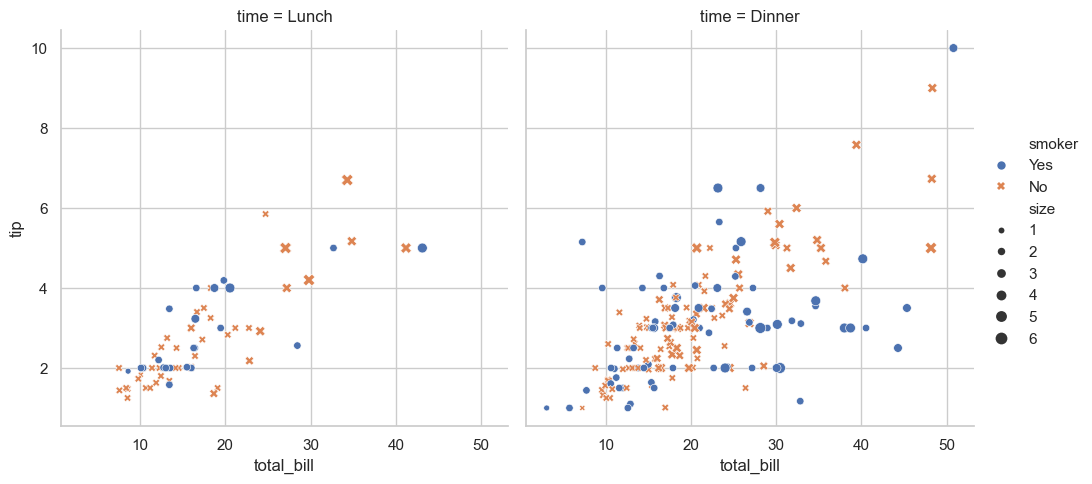

In [9]:
# sns.relplot() adalah figure-level function untuk membuat relational plot
# Parameter yang digunakan:
# - data=tips        : menggunakan DataFrame tips sebagai sumber data
# - x="total_bill"   : kolom total_bill sebagai sumbu X
# - y="tip"          : kolom tip sebagai sumbu Y
# - col="time"       : membuat subplot terpisah berdasarkan kolom 'time' (Lunch/Dinner)
# - hue="smoker"     : membedakan warna titik berdasarkan status perokok (Yes/No)
# - style="smoker"   : membedakan bentuk marker berdasarkan status perokok (Yes/No)
# - size="size"      : mengatur ukuran titik berdasarkan jumlah orang dalam kelompok

# Hasil: 2 subplot (Lunch & Dinner) berisi scatter plot
# yang menunjukkan hubungan antara total tagihan dan tip,
# dengan warna & bentuk berbeda untuk perokok/non-perokok,
# serta ukuran titik sesuai jumlah orang

sns.relplot(
    data=tips,
    x="total_bill", y="tip", col="time",
    hue="smoker", style="smoker", size="size",
)
plt.show()

In [10]:
dots = sns.load_dataset("dots")
dots.head()

,align,choice,time,coherence,firing_rate
0,dots,T1,-80,0.0,33.189967
1,dots,T1,-80,3.2,31.691726
2,dots,T1,-80,6.4,34.279840
3,dots,T1,-80,12.8,32.631874
4,dots,T1,-80,25.6,35.060487


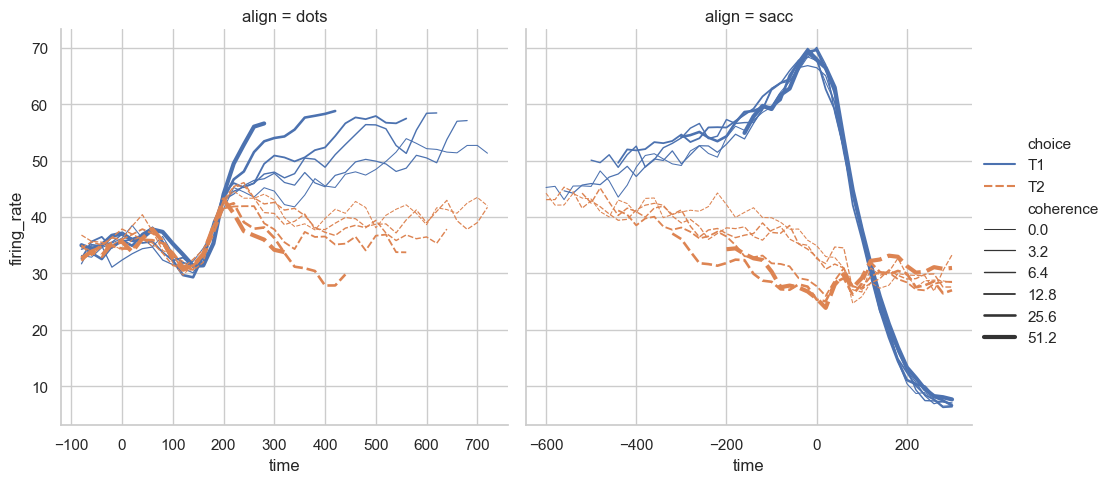

In [11]:
# sns.relplot() dengan kind="line" membuat line plot dengan figure-level interface
# Parameter yang digunakan:
# - data=dots          : menggunakan DataFrame dots sebagai sumber data
# - kind="line"        : membuat line plot (bukan scatter plot)
# - x="time"           : kolom time sebagai sumbu X (waktu dalam milidetik)
# - y="firing_rate"    : kolom firing_rate sebagai sumbu Y (tingkat aktivitas neuron)
# - col="align"        : membuat subplot terpisah berdasarkan kolom 'align' (dots/sacc)
# - hue="choice"       : membedakan warna garis berdasarkan pilihan (T1/T2)
# - size="coherence"   : mengatur ketebalan garis berdasarkan nilai coherence
# - style="choice"     : membedakan style/dash garis berdasarkan pilihan (T1/T2)
# - facet_kws=dict(sharex=False) : setiap subplot memiliki skala sumbu X yang independen
#                                  (tidak berbagi skala X yang sama antar subplot)

# Hasil: 2 subplot (dots & sacc) berisi line plot
# yang menunjukkan perubahan firing rate terhadap waktu,
# dengan warna & style garis berbeda untuk setiap choice (T1/T2),
# serta ketebalan garis sesuai nilai coherence

sns.relplot(
    data=dots, kind="line",
    x="time", y="firing_rate", col="align",
    hue="choice", size="coherence", style="choice",
    facet_kws=dict(sharex=False),
)
plt.show()

In [34]:
# Load dataset fMRI (functional Magnetic Resonance Imaging)
fmri = sns.load_dataset("fmri")
fmri.head()

,subject,timepoint,event,region,signal
0,s13,18,stim,parietal,-0.017552
1,s5,14,stim,parietal,-0.080883
2,s12,18,stim,parietal,-0.081033
3,s11,18,stim,parietal,-0.046134
4,s10,18,stim,parietal,-0.037970


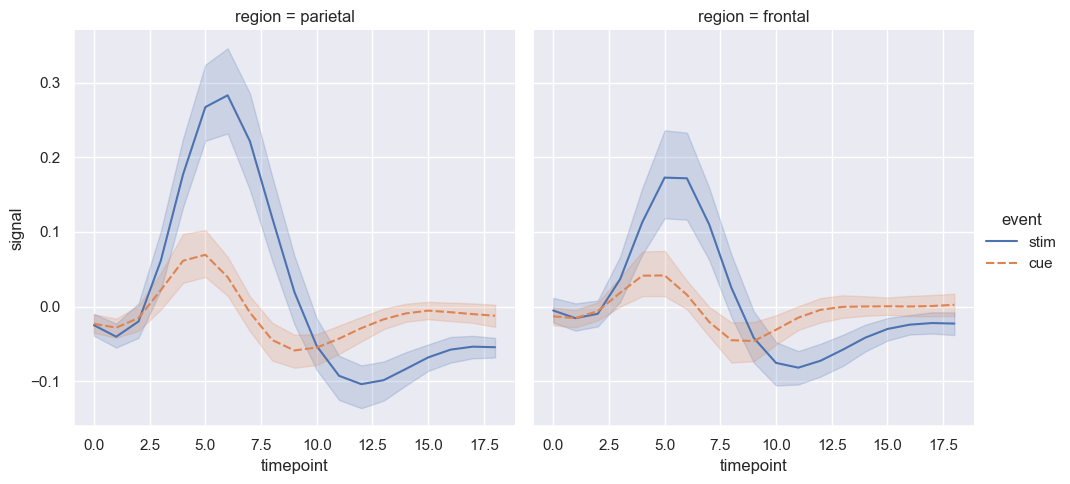

In [35]:
# sns.relplot() dengan kind="line" untuk statistical estimation
# Parameter yang digunakan:
# - data=fmri          : menggunakan DataFrame fmri sebagai sumber data
# - kind="line"        : membuat line plot dengan estimasi statistik
# - x="timepoint"      : kolom timepoint sebagai sumbu X (waktu pengamatan)
# - y="signal"         : kolom signal sebagai sumbu Y (intensitas sinyal fMRI)
# - col="region"       : membuat subplot terpisah berdasarkan region otak
# - hue="event"        : membedakan warna garis berdasarkan jenis event (cue/stim)
# - style="event"      : membedakan style garis berdasarkan jenis event

# Hasil: Subplot untuk setiap region otak yang menunjukkan 
# perubahan signal fMRI terhadap timepoint,
# dengan garis dan warna berbeda untuk setiap event,
# termasuk confidence interval (shaded area) di sekitar garis

sns.relplot(
    data=fmri, kind="line",
    x="timepoint", y="signal", col="region",
    hue="event", style="event",
)
plt.show()

### 2.1 Relational Plots

Relational plots digunakan untuk memahami hubungan antara dua atau lebih variabel.

**Fungsi Utama:**
- `scatterplot()` - Scatter plot untuk melihat hubungan antar variabel
- `lineplot()` - Line plot untuk data time-series atau trend
- `relplot()` - Figure-level interface untuk relational plots

### 2.3 Categorical Plots

Categorical plots digunakan untuk memvisualisasikan data dengan variabel kategorikal.

**Fungsi Utama:**

**A. Distribusi Kategorikal:**
- `stripplot()` - Strip plot (scatter plot kategorikal)
- `swarmplot()` - Swarm plot (non-overlapping points)
- .. dll

**B. Estimasi Statistik:**
- `boxplot()` - Box plot
- `violinplot()` - Violin plot
- `boxenplot()` - Enhanced box plot
- .. dll

**C. Estimasi dengan Error Bar:**
- `barplot()` - Bar plot dengan confidence interval
- `pointplot()` - Point plot dengan error bars
- `countplot()` - Count plot untuk menghitung frekuensi
- ..dll

**D. Figure-level:**
- `catplot()` - Figure-level interface untuk categorical plots
- .. dll

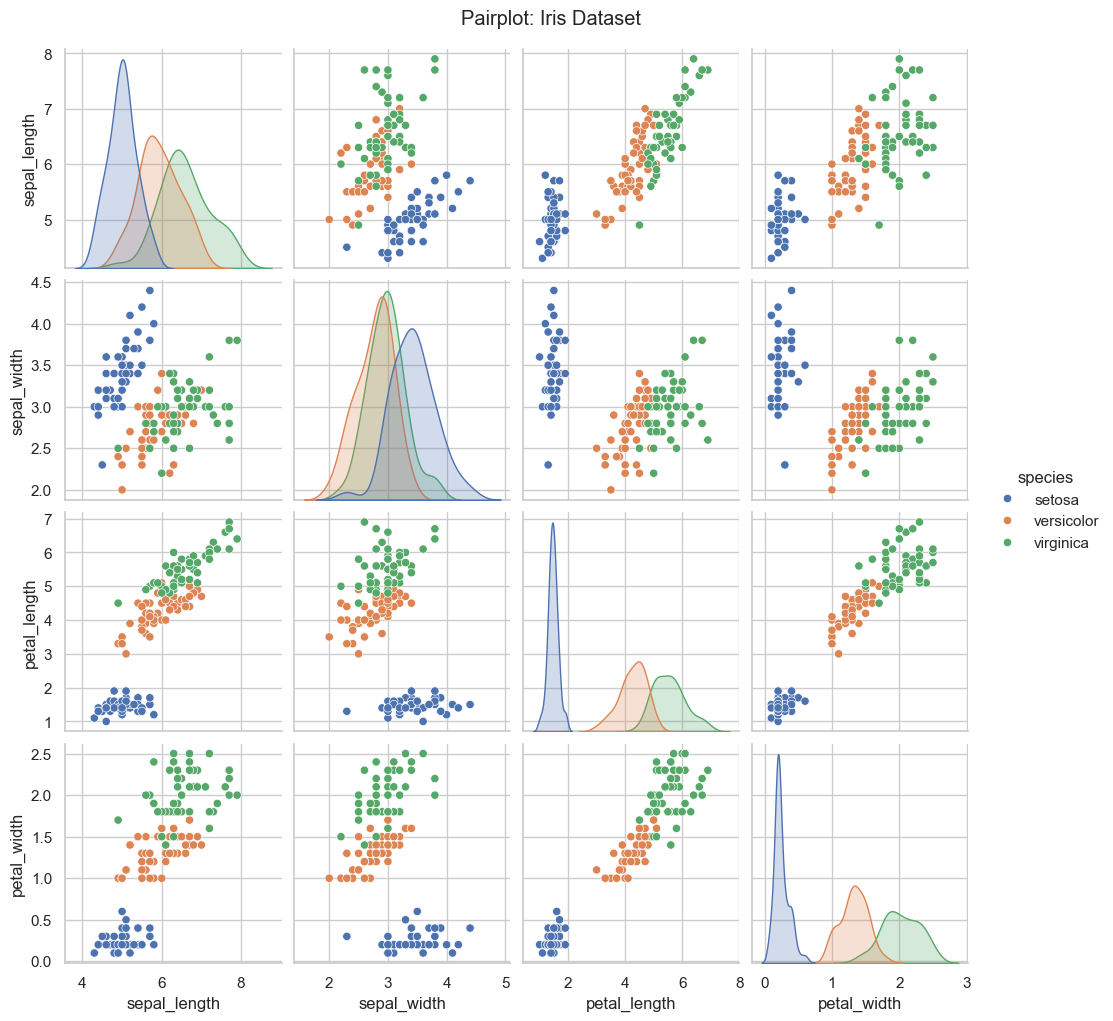

In [13]:
# Contoh 1: Pairplot - Melihat relasi antar semua variabel
g = sns.pairplot(iris, hue='species', diag_kind='kde', height=2.5)
g.fig.suptitle('Pairplot: Iris Dataset', y=1.02)
plt.show()

In [14]:
# Eksplorasi Dataset Titanic
print("Dataset Titanic:")
print(titanic.head())
print(f"\nShape: {titanic.shape}")
print(f"\nInfo:")
print(titanic.info())
print(f"\nMissing values:\n{titanic.isnull().sum()}")
print(f"\nDeskripsi Statistik:\n{titanic.describe()}")

Dataset Titanic:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Shape: (891, 15)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  ----- 

## Referensi Cepat: Seaborn Cheat Sheet

### Import & Setup
```python
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='whitegrid')
```

### Load Data
```python
# Built-in datasets
df = sns.load_dataset('tips')

# Custom data
df = pd.read_csv('data.csv')
```

### Plot Types

#### Relational
```python
sns.scatterplot(data=df, x='col1', y='col2', hue='category')
sns.lineplot(data=df, x='x', y='y')
sns.relplot(data=df, x='x', y='y', col='category')
```

#### Distribution
```python
sns.histplot(data=df, x='col', kde=True)
sns.kdeplot(data=df, x='col', fill=True)
sns.displot(data=df, x='col', hue='category')
```

#### Categorical
```python
sns.boxplot(data=df, x='category', y='value')
sns.violinplot(data=df, x='category', y='value')
sns.barplot(data=df, x='category', y='value')
sns.countplot(data=df, x='category')
```

#### Matrix
```python
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
sns.clustermap(df, standard_scale=1)
```

#### Multi-plot
```python
sns.pairplot(df, hue='category')
sns.jointplot(data=df, x='x', y='y', kind='reg')
```

### Customization
```python
# Style
sns.set_style('whitegrid')  # darkgrid, white, dark, ticks

# Palette
sns.set_palette('husl')  # deep, muted, bright, pastel, dark

# Context
sns.set_context('talk')  # paper, notebook, talk, poster

# Color
palette = sns.color_palette('viridis', 5)
```

### Save Figure
```python
plt.savefig('plot.png', dpi=300, bbox_inches='tight')
```

### Common Parameters
- `data`: DataFrame
- `x`, `y`: Column names
- `hue`: Color by category
- `size`: Size by value
- `style`: Marker style by category
- `col`, `row`: Create subplots
- `palette`: Color palette
- `figsize`: Figure size (width, height)

## Resources dan Referensi

### Dokumentasi Resmi
- 📚 [Seaborn Official Documentation](https://seaborn.pydata.org/)
- 📖 [Seaborn Tutorial](https://seaborn.pydata.org/tutorial.html)
- 🎨 [Seaborn Gallery](https://seaborn.pydata.org/examples/index.html)
- 🔍 [Choosing the right plot type](https://seaborn.pydata.org/tutorial/function_overview.html)

### Dataset untuk Latihan
- Gunakan `sns.load_dataset()` untuk mengakses berbagai dataset built-in
- Dataset populer: tips, iris, titanic, diamonds, flights, planets

### Tips Belajar Lebih Lanjut
1. Praktikkan dengan dataset Anda sendiri
2. Eksplorasi berbagai kombinasi parameter
3. Pelajari dari contoh di Seaborn Gallery
4. Gabungkan dengan Matplotlib untuk customization lebih lanjut
5. Ikuti best practices untuk data visualization

---

**Selamat belajar dan bereksperimen dengan Seaborn!** 🎨📊✨

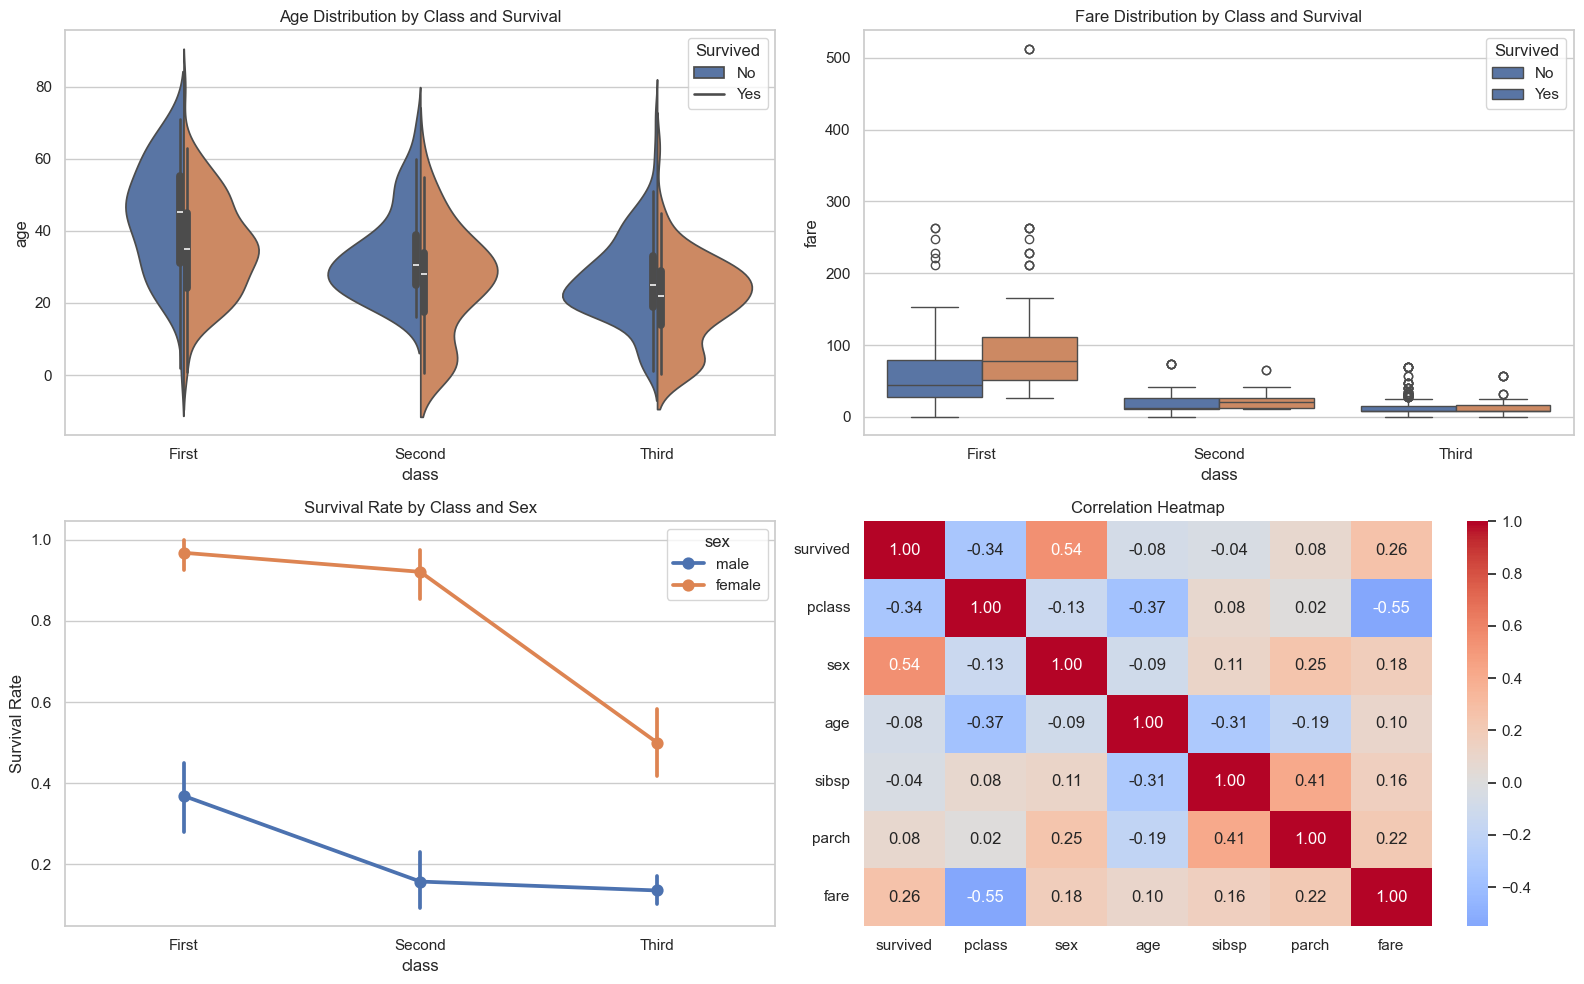

In [15]:
# Visualisasi 2: Advanced Analysis
fig = plt.figure(figsize=(16, 10))

# Violin plot: Age by Class and Survival
plt.subplot(2, 2, 1)
sns.violinplot(data=titanic, x='class', y='age', hue='survived', split=True)
plt.title('Age Distribution by Class and Survival')
plt.legend(title='Survived', labels=['No', 'Yes'])

# Box plot: Fare by Class
plt.subplot(2, 2, 2)
sns.boxplot(data=titanic, x='class', y='fare', hue='survived')
plt.title('Fare Distribution by Class and Survival')
plt.legend(title='Survived', labels=['No', 'Yes'])

# Point plot: Survival rate by class and sex
plt.subplot(2, 2, 3)
sns.pointplot(data=titanic, x='class', y='survived', hue='sex')
plt.title('Survival Rate by Class and Sex')
plt.ylabel('Survival Rate')

# Heatmap
plt.subplot(2, 2, 4)
# Prepare data untuk heatmap
titanic_encoded = titanic.copy()
titanic_encoded['sex'] = titanic_encoded['sex'].map({'male': 0, 'female': 1})
titanic_encoded['class'] = titanic_encoded['class'].map({'First': 1, 'Second': 2, 'Third': 3})
corr_cols = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']
correlation = titanic_encoded[corr_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

/var/folders/k3/03k08prs08l1tb44r35bvtrm0000gn/T/ipykernel_1168/2783835935.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['No', 'Yes'])


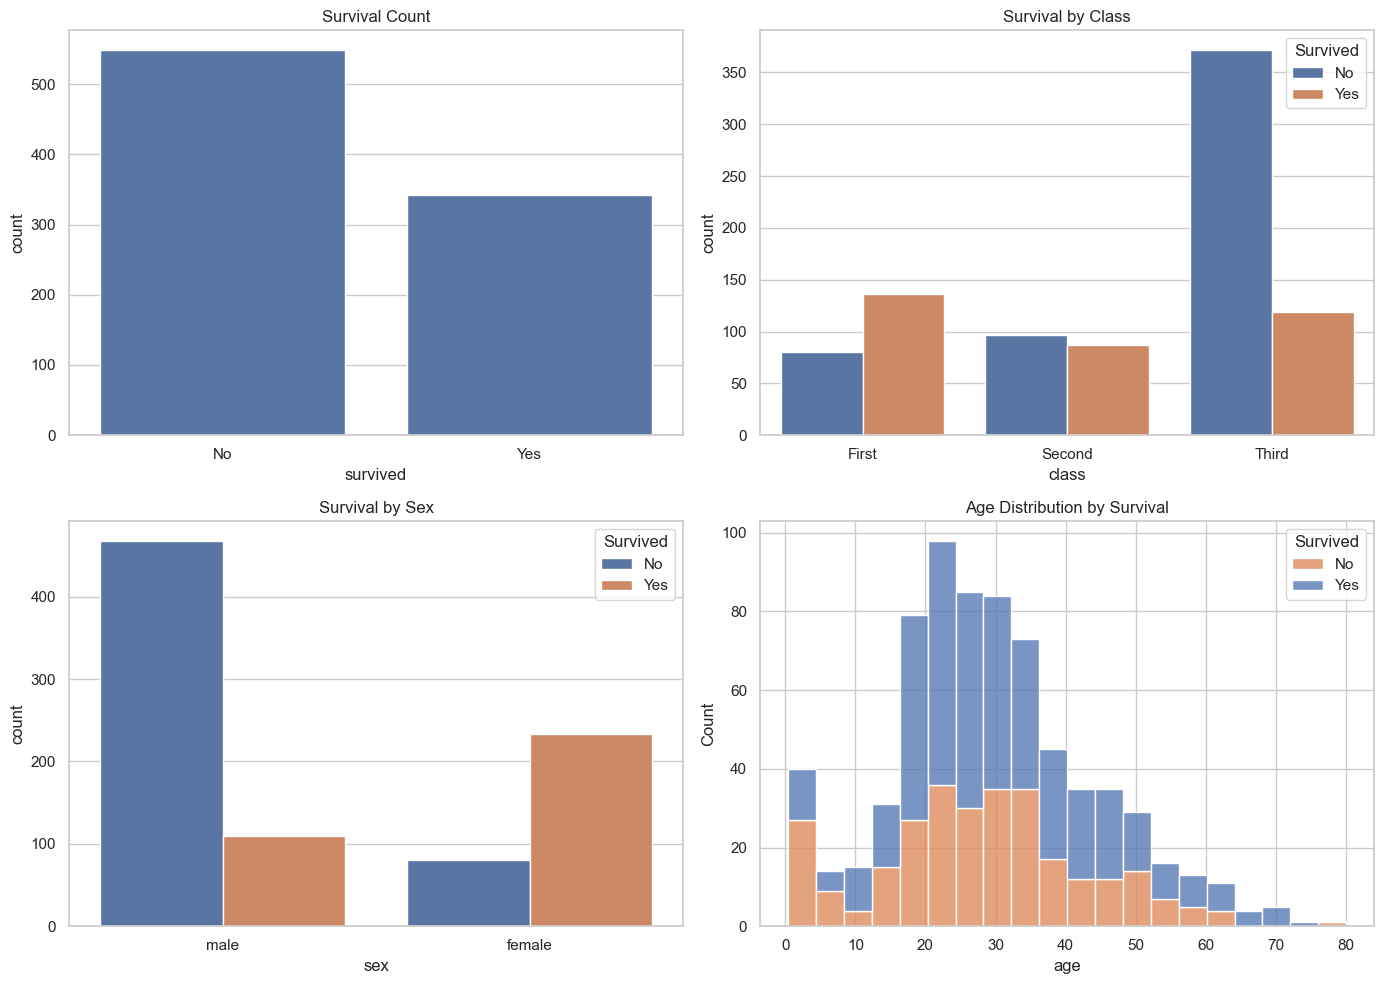

In [16]:
# Visualisasi 1: Survival Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Survival count
sns.countplot(data=titanic, x='survived', ax=axes[0, 0])
axes[0, 0].set_title('Survival Count')
axes[0, 0].set_xticklabels(['No', 'Yes'])

# Survival by class
sns.countplot(data=titanic, x='class', hue='survived', ax=axes[0, 1])
axes[0, 1].set_title('Survival by Class')
axes[0, 1].legend(title='Survived', labels=['No', 'Yes'])

# Survival by sex
sns.countplot(data=titanic, x='sex', hue='survived', ax=axes[1, 0])
axes[1, 0].set_title('Survival by Sex')
axes[1, 0].legend(title='Survived', labels=['No', 'Yes'])

# Age distribution by survival
sns.histplot(data=titanic, x='age', hue='survived', multiple='stack', ax=axes[1, 1])
axes[1, 1].set_title('Age Distribution by Survival')
axes[1, 1].legend(title='Survived', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

## Latihan Praktis: Exploratory Data Analysis dengan Titanic Dataset

Mari kita terapkan berbagai teknik yang telah dipelajari untuk menganalisis dataset Titanic.

## Tips dan Best Practices

### 1. Memilih Plot yang Tepat

- **Hubungan antar variabel**: scatterplot, lineplot, regplot
- **Distribusi data**: histplot, kdeplot, violinplot
- **Perbandingan kategori**: barplot, boxplot, violinplot
- **Korelasi multiple variables**: heatmap, pairplot
- **Time series**: lineplot

### 2. Penggunaan Warna

- Gunakan `hue` untuk membedakan kategori
- Pilih palette yang sesuai dengan data (sequential, diverging, categorical)
- Gunakan colorblind-friendly palettes jika memungkinkan

### 3. Faceting

- Gunakan `col` dan `row` untuk membuat subplot berdasarkan kategori
- Gunakan `FacetGrid` untuk kontrol yang lebih detail
- Gunakan `relplot`, `displot`, `catplot` untuk faceting otomatis

### 4. Figure-level vs Axes-level

- **Figure-level functions** (`relplot`, `displot`, `catplot`): Membuat figure sendiri, support faceting
- **Axes-level functions** (`scatterplot`, `histplot`, `boxplot`): Bekerja dengan axes yang sudah ada

### 5. Performance

- Untuk dataset besar, pertimbangkan sampling atau aggregasi
- Gunakan `kde` dengan hati-hati untuk dataset besar
- Gunakan `rasterized=True` untuk mengurangi ukuran file

/var/folders/k3/03k08prs08l1tb44r35bvtrm0000gn/T/ipykernel_1168/2222001924.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tips, x='day', y='total_bill', palette=palette, ax=axes[i])
/var/folders/k3/03k08prs08l1tb44r35bvtrm0000gn/T/ipykernel_1168/2222001924.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tips, x='day', y='total_bill', palette=palette, ax=axes[i])
/var/folders/k3/03k08prs08l1tb44r35bvtrm0000gn/T/ipykernel_1168/2222001924.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tips, x='day', y='total_bill', 

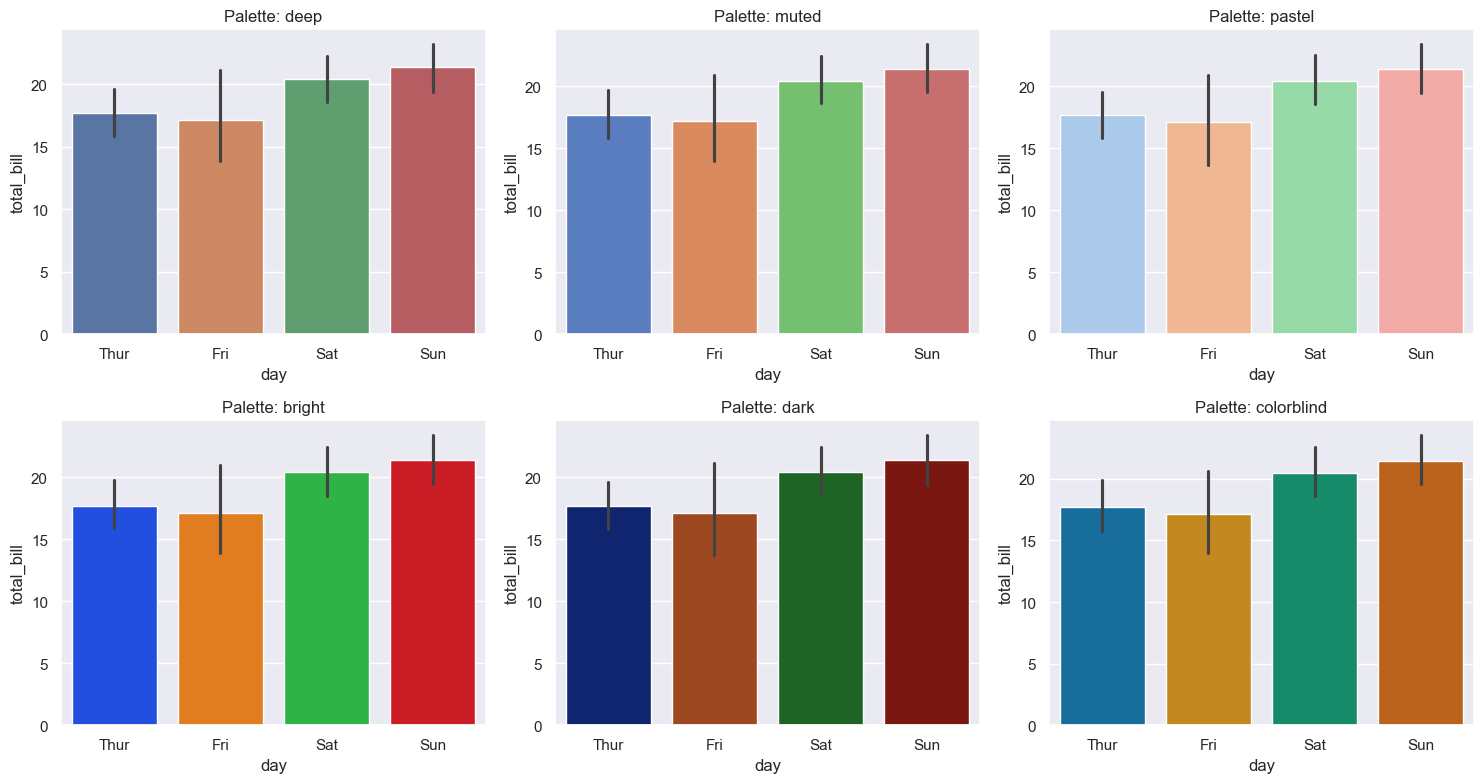

In [36]:
# Contoh: Color Palettes
palettes = ['deep', 'muted', 'pastel', 'bright', 'dark', 'colorblind']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, palette in enumerate(palettes):
    sns.barplot(data=tips, x='day', y='total_bill', palette=palette, ax=axes[i])
    axes[i].set_title(f'Palette: {palette}')

plt.tight_layout()
plt.show()

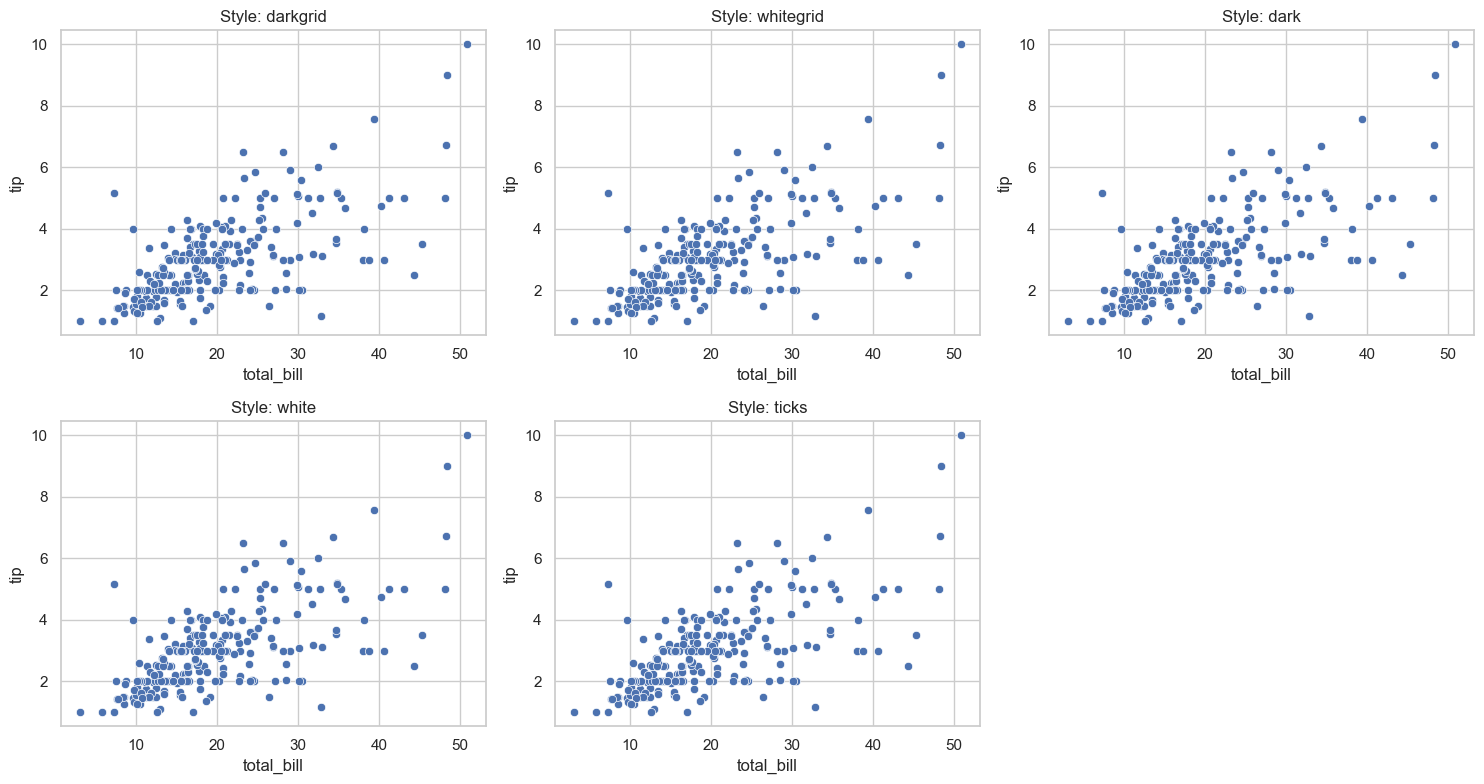

In [18]:
# Contoh: Berbagai Style Seaborn
styles = ['darkgrid', 'whitegrid', 'dark', 'white', 'ticks']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, style in enumerate(styles):
    sns.set_style(style)
    sns.scatterplot(data=tips, x='total_bill', y='tip', ax=axes[i])
    axes[i].set_title(f'Style: {style}')

# Hide the last subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

# Reset ke default
sns.set_theme()

### 2.6 Customization dan Styling

Seaborn menyediakan berbagai cara untuk mengkustomisasi tampilan grafik.

**Tema dan Style:**
- `set_theme()` - Set tema keseluruhan
- `set_style()` - Set style: 'darkgrid', 'whitegrid', 'dark', 'white', 'ticks'
- `set_palette()` - Set color palette
- `set_context()` - Set context: 'paper', 'notebook', 'talk', 'poster'

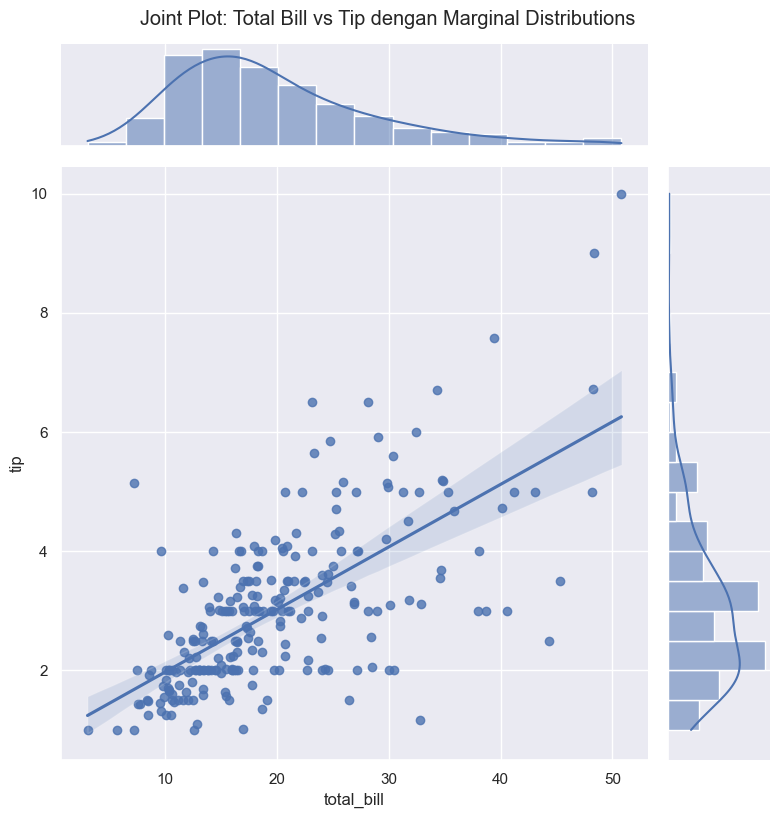

In [19]:
# Contoh 3: Jointplot - Plot dengan marginal distributions
g = sns.jointplot(data=tips, x='total_bill', y='tip', kind='reg', height=8)
g.fig.suptitle('Joint Plot: Total Bill vs Tip dengan Marginal Distributions', y=1.02)
plt.show()

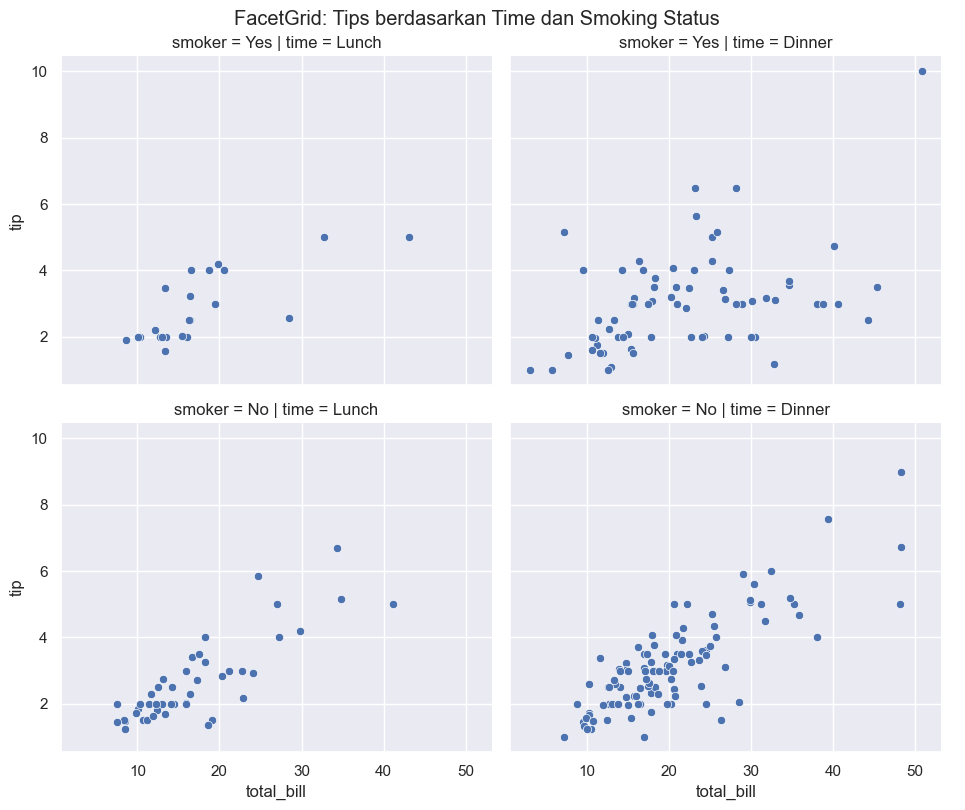

In [20]:
# Contoh 2: FacetGrid - Custom multi-plot
g = sns.FacetGrid(tips, col='time', row='smoker', height=4, aspect=1.2)
g.map(sns.scatterplot, 'total_bill', 'tip')
g.add_legend()
g.fig.suptitle('FacetGrid: Tips berdasarkan Time dan Smoking Status', y=1.01)
plt.show()

### 2.5 Multi-plot Grids

Multi-plot grids memungkinkan pembuatan subplot yang kompleks dengan mudah.

**Fungsi Utama:**
- `FacetGrid()` - Grid untuk membuat multiple plots berdasarkan kategori
- `PairGrid()` - Grid untuk membuat pairwise relationships
- `pairplot()` - Shortcut untuk membuat pairplot
- `JointGrid()` - Grid untuk plot dengan marginal distributions
- `jointplot()` - Shortcut untuk joint plot

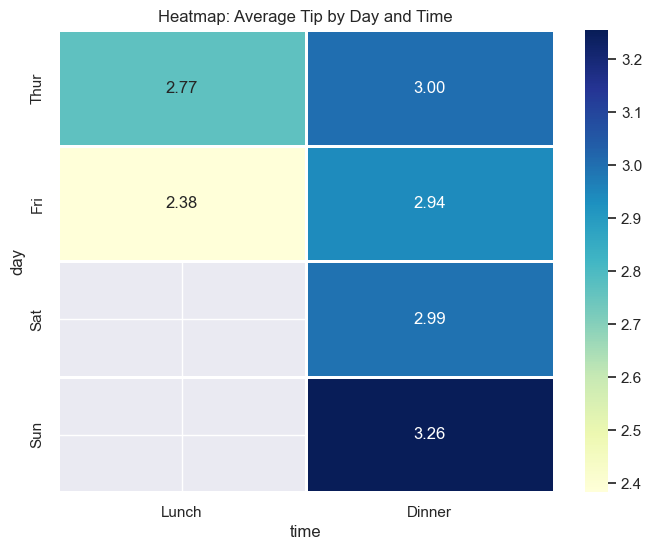

In [21]:
# Contoh 2: Heatmap dengan Data Pivot
# Membuat pivot table
pivot_data = tips.pivot_table(values='tip', index='day', columns='time', aggfunc='mean')

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_data, annot=True, fmt='.2f', cmap='YlGnBu', linewidths=1)
plt.title('Heatmap: Average Tip by Day and Time')
plt.show()

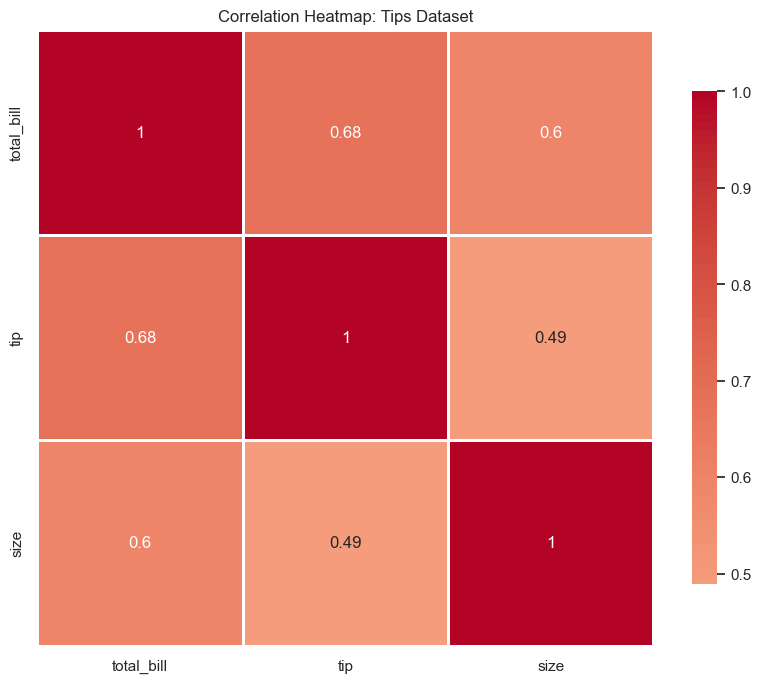

In [22]:
# Contoh 1: Heatmap - Correlation Matrix
plt.figure(figsize=(10, 8))

# Menghitung correlation matrix
correlation = tips.select_dtypes(include=[np.number]).corr()

# Membuat heatmap
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap: Tips Dataset')
plt.show()

### 2.4 Matrix Plots

Matrix plots menampilkan data dalam format matriks, sangat berguna untuk correlation analysis.

**Fungsi Utama:**
- `heatmap()` - Heatmap untuk matriks data
- `clustermap()` - Heatmap dengan hierarchical clustering

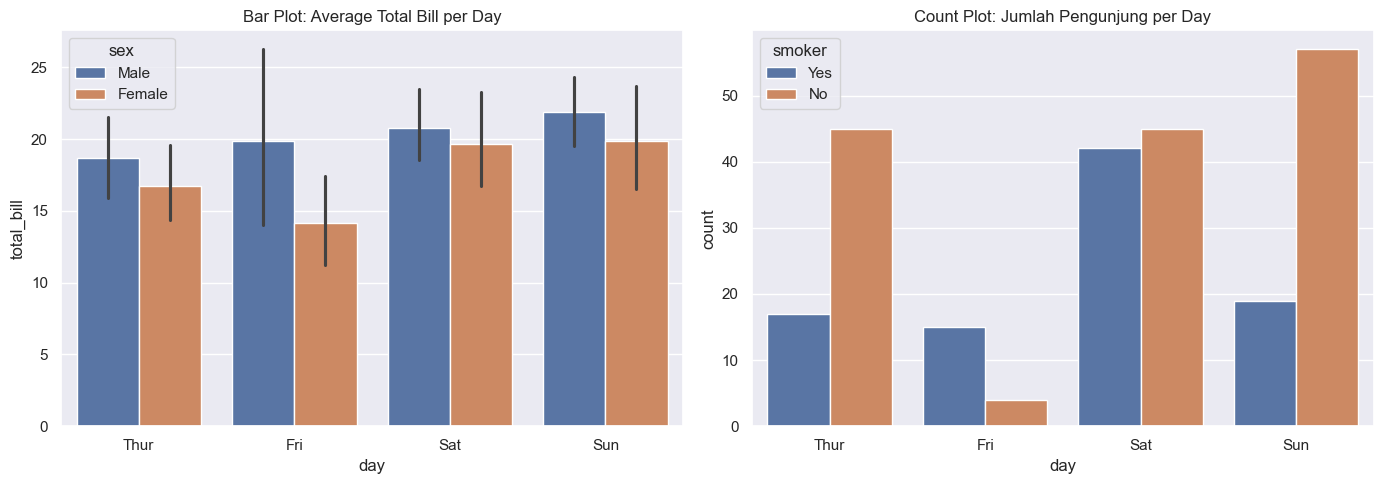

In [23]:
# Contoh 3: Bar Plot dan Count Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot (menampilkan rata-rata dengan confidence interval)
sns.barplot(data=tips, x='day', y='total_bill', hue='sex', ax=axes[0])
axes[0].set_title('Bar Plot: Average Total Bill per Day')

# Count plot (menghitung frekuensi)
sns.countplot(data=tips, x='day', hue='smoker', ax=axes[1])
axes[1].set_title('Count Plot: Jumlah Pengunjung per Day')

plt.tight_layout()
plt.show()

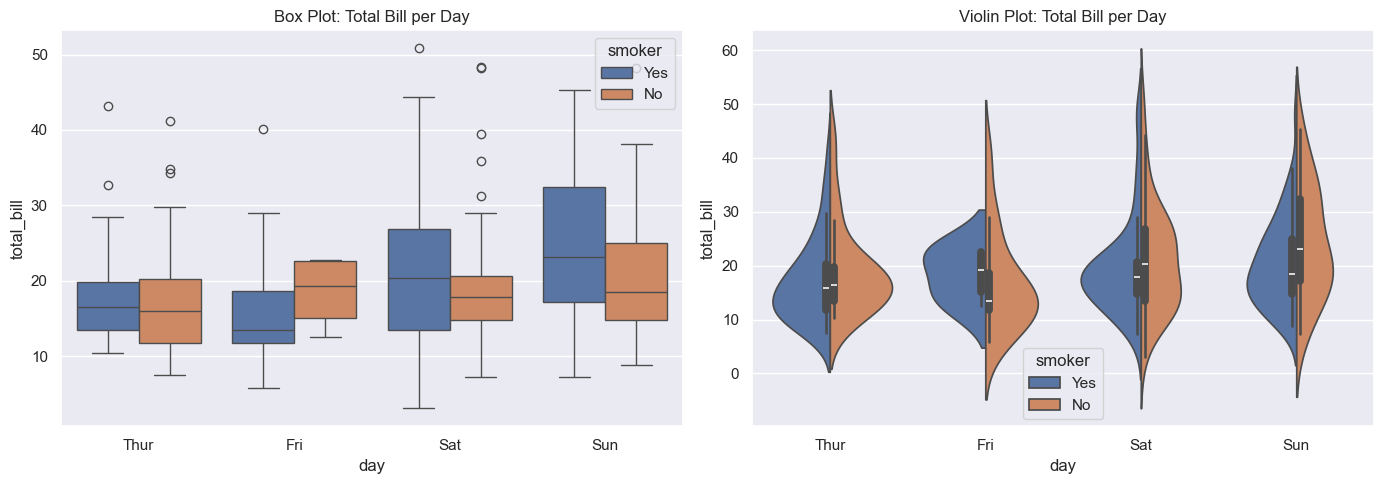

In [24]:
# Contoh 2: Box Plot dan Violin Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(data=tips, x='day', y='total_bill', hue='smoker', ax=axes[0])
axes[0].set_title('Box Plot: Total Bill per Day')

# Violin plot
sns.violinplot(data=tips, x='day', y='total_bill', hue='smoker', split=True, ax=axes[1])
axes[1].set_title('Violin Plot: Total Bill per Day')

plt.tight_layout()
plt.show()

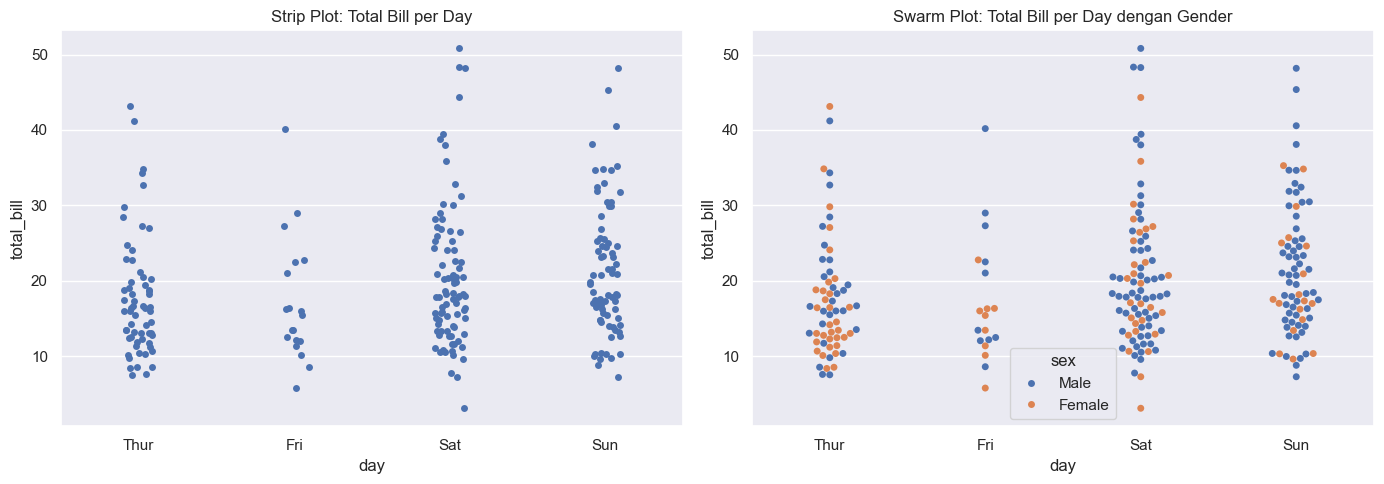

In [25]:
# Contoh 1: Strip Plot dan Swarm Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Strip plot
sns.stripplot(data=tips, x='day', y='total_bill', ax=axes[0])
axes[0].set_title('Strip Plot: Total Bill per Day')

# Swarm plot (points tidak overlap)
sns.swarmplot(data=tips, x='day', y='total_bill', hue='sex', ax=axes[1])
axes[1].set_title('Swarm Plot: Total Bill per Day dengan Gender')

plt.tight_layout()
plt.show()

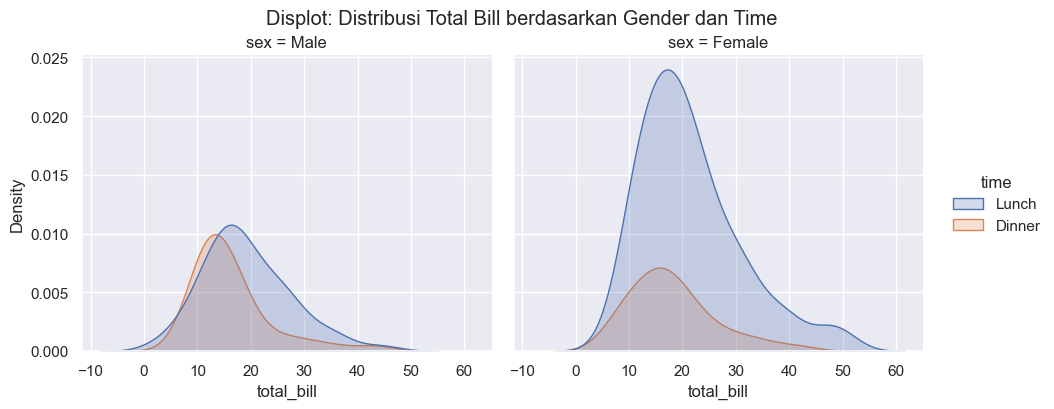

In [26]:
# Contoh 3: Displot (Figure-level)
g = sns.displot(
    data=tips, 
    x='total_bill',
    hue='time',
    col='sex',
    kind='kde',
    fill=True,
    height=4,
    aspect=1.2
)
g.fig.suptitle('Displot: Distribusi Total Bill berdasarkan Gender dan Time', y=1.02)
plt.show()

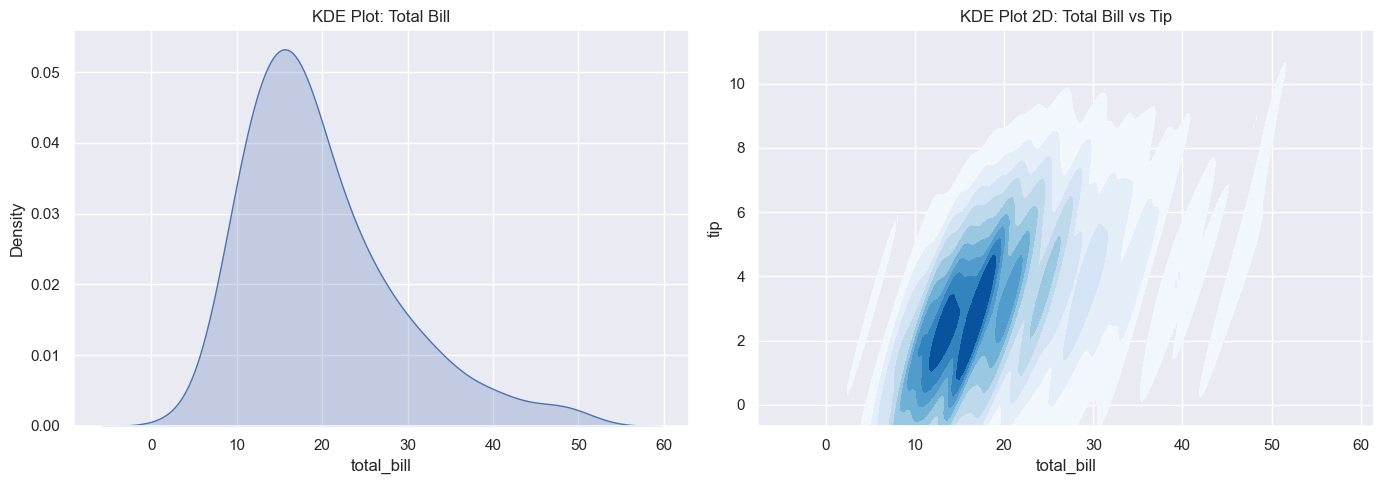

In [27]:
# Contoh 2: KDE Plot (Kernel Density Estimate)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE plot univariate
sns.kdeplot(data=tips, x='total_bill', ax=axes[0], fill=True)
axes[0].set_title('KDE Plot: Total Bill')

# KDE plot bivariate (2D)
sns.kdeplot(data=tips, x='total_bill', y='tip', ax=axes[1], fill=True, cmap='Blues')
axes[1].set_title('KDE Plot 2D: Total Bill vs Tip')

plt.tight_layout()
plt.show()

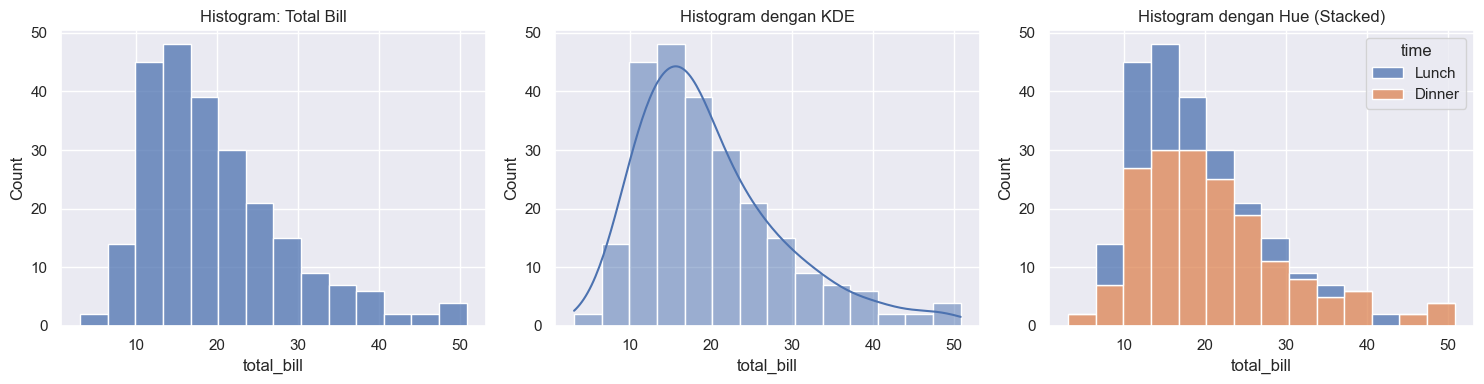

In [28]:
# Contoh 1: Histogram
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram sederhana
sns.histplot(data=tips, x='total_bill', ax=axes[0])
axes[0].set_title('Histogram: Total Bill')

# Histogram dengan KDE
sns.histplot(data=tips, x='total_bill', kde=True, ax=axes[1])
axes[1].set_title('Histogram dengan KDE')

# Histogram dengan hue
sns.histplot(data=tips, x='total_bill', hue='time', multiple='stack', ax=axes[2])
axes[2].set_title('Histogram dengan Hue (Stacked)')

plt.tight_layout()
plt.show()

### 2.2 Distribution Plots

Distribution plots membantu memvisualisasikan distribusi dari satu atau lebih variabel.

**Fungsi Utama:**
- `histplot()` - Histogram untuk distribusi data
- `kdeplot()` - Kernel Density Estimate plot
- `ecdfplot()` - Empirical Cumulative Distribution Function
- `rugplot()` - Rug plot (garis vertikal untuk setiap observasi)
- `displot()` - Figure-level interface untuk distribution plots

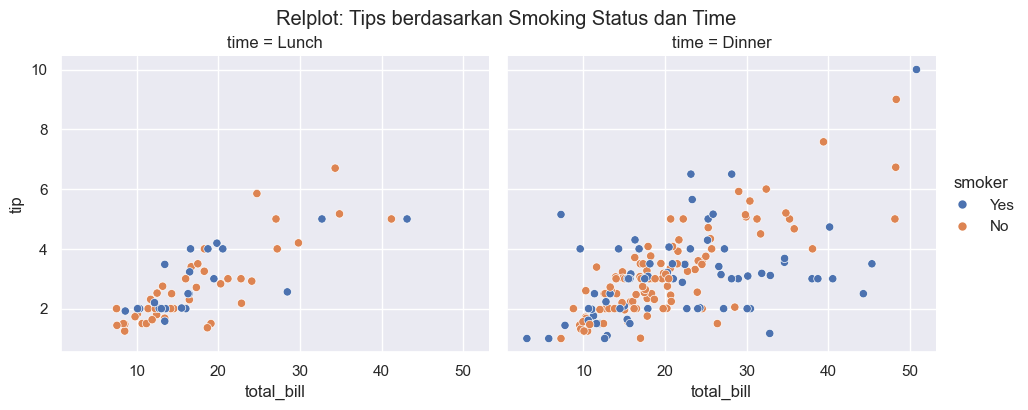

In [29]:
# Contoh 3: Relplot (Figure-level)
# Relplot memungkinkan faceting (membuat subplot berdasarkan kategori)
g = sns.relplot(
    data=tips, 
    x='total_bill', 
    y='tip',
    hue='smoker',
    col='time',
    kind='scatter',
    height=4,
    aspect=1.2
)
g.fig.suptitle('Relplot: Tips berdasarkan Smoking Status dan Time', y=1.02)
plt.show()

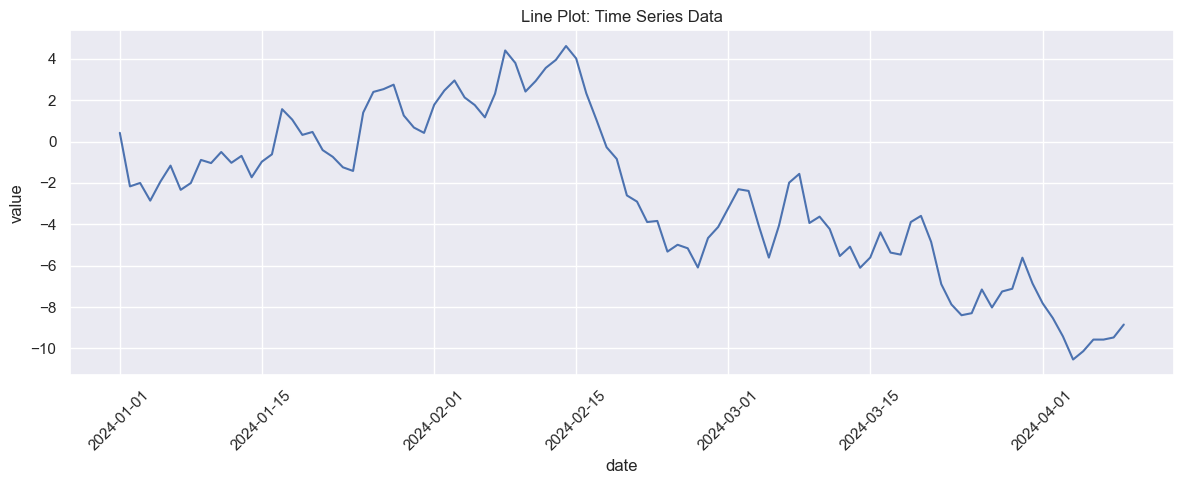

In [30]:
# Contoh 2: Line Plot
# Membuat data time-series sederhana
dates = pd.date_range('2024-01-01', periods=100)
values = np.cumsum(np.random.randn(100))
df_time = pd.DataFrame({'date': dates, 'value': values})

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_time, x='date', y='value')
plt.title('Line Plot: Time Series Data')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

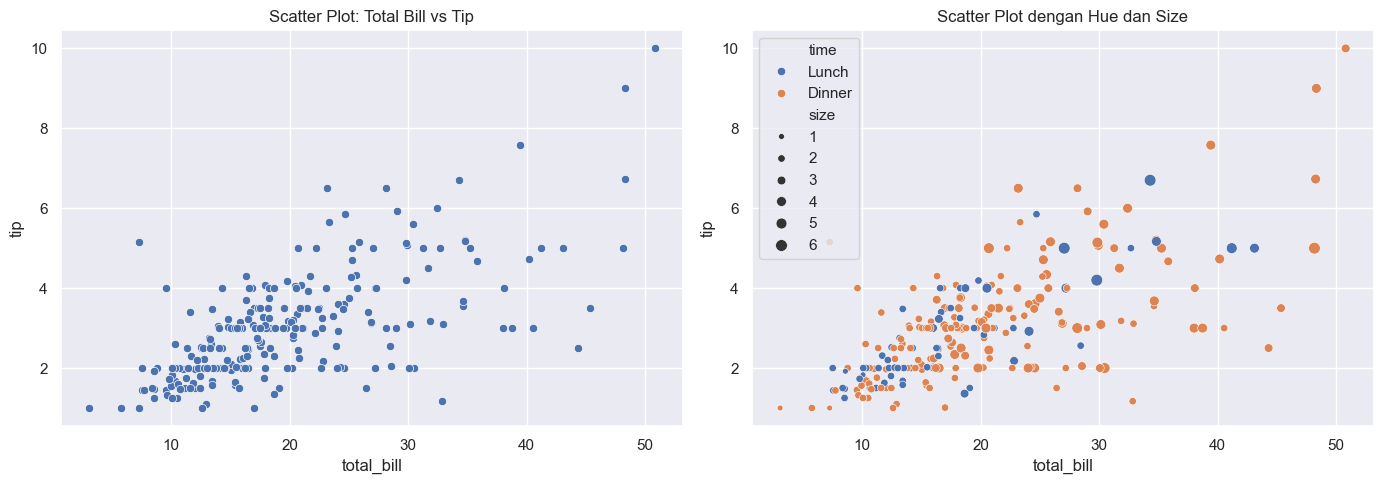

In [31]:
# Contoh 1: Scatter Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot sederhana
sns.scatterplot(data=tips, x='total_bill', y='tip', ax=axes[0])
axes[0].set_title('Scatter Plot: Total Bill vs Tip')

# Scatter plot dengan hue (warna berdasarkan kategori)
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='time', size='size', ax=axes[1])
axes[1].set_title('Scatter Plot dengan Hue dan Size')

plt.tight_layout()
plt.show()

## 2. Overview of Seaborn Plotting Functions

Seaborn memiliki berbagai fungsi plotting yang dapat dikategorikan menjadi beberapa kelompok:

### Kategori Fungsi Plotting dalam Seaborn:

1. **Relational Plots** - Menampilkan hubungan antar variabel
2. **Distribution Plots** - Menampilkan distribusi data
3. **Categorical Plots** - Menampilkan data kategorikal
4. **Regression Plots** - Menampilkan hubungan linear
5. **Matrix Plots** - Menampilkan data dalam bentuk matriks
6. **Multi-plot Grids** - Membuat subplot yang kompleks

In [32]:
# Load beberapa dataset populer untuk contoh
tips = sns.load_dataset('tips')
iris = sns.load_dataset('iris')
titanic = sns.load_dataset('titanic')

# Melihat struktur dataset tips
print("Dataset Tips (contoh data restoran):")
print(tips.head())
print(f"\nShape: {tips.shape}")
print(f"\nInfo:")
print(tips.info())

Dataset Tips (contoh data restoran):
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Shape: (244, 7)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None


In [33]:
# Melihat daftar dataset yang tersedia
print("Dataset yang tersedia di Seaborn:")
print(sns.get_dataset_names())

Dataset yang tersedia di Seaborn:
['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


### Dataset Bawaan Seaborn

Seaborn menyediakan beberapa dataset built-in yang sangat berguna untuk latihan dan eksplorasi.